# Stage 05: the arrangement generator

**Every feasible arrangement over the parsed grid — or a seeded,
representative sample when there are too many to hold.**

An arrangement is a choice of grid lines plus a rule for which crossings get
a column. Both endpoint lines on each axis always stay; every subset of the
interior lines whose bay widths respect the user's span limits is valid.
Blocked nodes (column-free zones) are removed, and removing one is only
allowed when its neighbours can still bridge the gap within the maximum
span.

Two things changed in this rebuild:

1. **Two placement policies.** For each surviving line set the generator
   emits the classic full **lattice** (a column at every unblocked node) and
   — when the plan carries wall thicknesses — a **walls** placement: a
   column only at nodes physically inside a load-bearing wall. The second
   policy is the one the corpus ground truth was derived with, which is
   what makes the derived arrangement one of the candidates rather than an
   unreachable ideal. Columns the drawing itself marks join every candidate
   under either policy.
2. **Sampling, not truncation.** The pair space of line subsets grows as
   2^lines; the old generator stopped at a cap, which filled the candidate
   set with near-identical dense grids and silently discarded the sparse
   end of the space. The generator now samples the pair space with a fixed
   seed when it overruns the cap, always keeping the full-line-set pair,
   so the candidate set stays representative at any cap.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

walls = json.loads((Path("..") / "data" / "sample_plan.json").read_text())["walls"]
cons = json.loads((Path("..") / "data" / "constraints.json").read_text())
grid = P.parse_plan(walls, cons)
arrs = P.generate(grid)
print(f"sample office, spans {cons['min_span']}-{cons['max_span']} m: "
      f"{len(arrs)} arrangements, all '{arrs[0]['placement']}' placement "
      f"(no wall thickness in this plan)")

sample office, spans 6.0-12.0 m: 33 arrangements, all 'lattice' placement (no wall thickness in this plan)


In [2]:
# A held-out dwelling: thickness-aware, so both policies appear.
plan = json.loads((Path("..") / "data" / "demo_plans" / "demo_01.json").read_text())
dcons = {"n_stories": plan["n_stories"], "min_span": 0.1, "max_span": 10.0,
         "merge_tol": "auto", "min_wall_frac": 0.05,
         "fixed_columns": plan.get("annotated_columns", []),
         "offer_skew_columns": False, "column_free_zones": []}
dgrid = P.parse_plan(plan["walls"], dcons)
dcands = P.generate(dgrid)
kinds = {}
for a in dcands:
    kinds[a["placement"]] = kinds.get(a["placement"], 0) + 1
counts = [len(a["columns"]) for a in dcands]
print(f"demo_01: {len(dcands)} candidates ({kinds}), "
      f"{min(counts)} to {max(counts)} columns")

demo_01: 3963 candidates ({'lattice': 1984, 'walls': 1979}), 5 to 57 columns


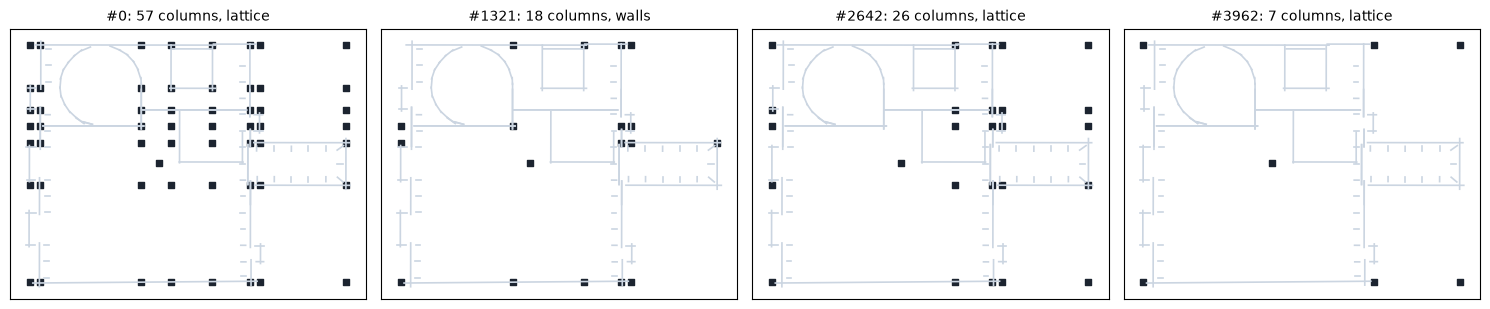

In [3]:
# Four candidates from across the space, walls in grey, columns in dark.
pick = [0, len(dcands) // 3, 2 * len(dcands) // 3, len(dcands) - 1]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, i in zip(axes, pick):
    a = dcands[i]
    for w in np.asarray(dgrid["walls"]):
        ax.plot([w[0], w[2]], [w[1], w[3]], color="#cbd5e1", lw=1.2)
    c = np.asarray(a["columns"])
    ax.scatter(c[:, 0], c[:, 1], s=22, c="#1c2430", marker="s")
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{i}: {len(c)} columns, {a['placement']}", fontsize=10)
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "05_example_arrangements.png",
            dpi=150, bbox_inches="tight")
plt.show()

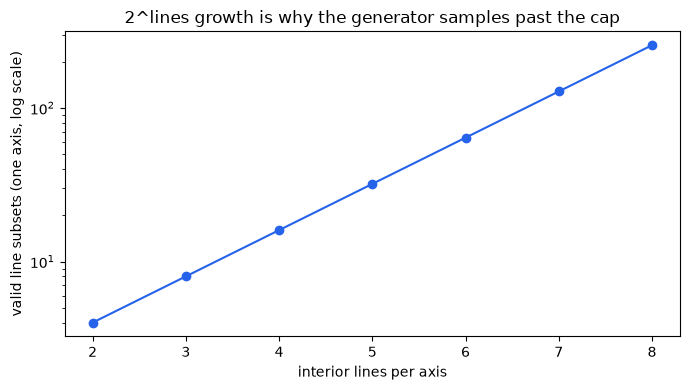

wrote data/arrangements.json (33 arrangements)


In [4]:
# How fast the space grows, and what the seeded sample does about it.
sizes = []
for k in range(2, 9):
    lines = np.linspace(0, 36, k + 2)
    sets_ = P.valid_line_sets(lines, 0.5, 40)
    sizes.append(len(sets_))
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(2, 9), sizes, "o-", color="#2563eb")
ax.set_xlabel("interior lines per axis")
ax.set_ylabel("valid line subsets (one axis, log scale)")
ax.set_title("2^lines growth is why the generator samples past the cap")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "05_search_space.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Hand the sample plan's arrangements to the next stage.
payload = [{"x_lines": np.asarray(a["x_lines"]).tolist(),
            "y_lines": np.asarray(a["y_lines"]).tolist(),
            "columns": np.asarray(a["columns"]).tolist(),
            "skew_columns": np.asarray(a["skew_columns"]).reshape(-1, 2).tolist(),
            "n_stories": a["n_stories"], "placement": a["placement"]}
           for a in arrs]
(Path("..") / "data" / "arrangements.json").write_text(json.dumps(payload))
print(f"wrote data/arrangements.json ({len(payload)} arrangements)")

## The cap is reported, never silent

At the default cap of 4,000, the held-out dwellings enumerate between ~500
candidates (demo_04, whose span limits prune hard) and the full 4,000
(sampled). Stage 12 records the candidate count per plan next to every
accuracy figure, and the reachability rate — whether the derived ground
truth is in the set at all — is reported before any of them.